# Direct Detection

In [44]:
# Library imports and params
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import interpolate

# Defining the fonts before plotting:

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "monospace",  # Use monospace font
    "text.latex.preamble": r"\usepackage{courier}"  # Use Courier font
})
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'font.family': 'monospace',  # monospace font
    "text.latex.preamble": r"\usepackage{courier}",
    'font.size': 25,
    'axes.titlesize': 25,
    'axes.labelsize': 25,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'legend.fontsize': 25,
    'figure.titlesize': 25,
})


In [45]:
### Constants and fixed parameters, carried over from Relic_Abundance.ipynb.

alpha = 1/137
alphaD = 0.1

mchi_over_ma = 0.6

OmegaDM = 0.265        # without the reduced Hubble constant factor

mp = 0.93827208816     # proton mass in GeV

cm2_to_GeVm2 = 2.5681894616e27          # 1 cm^2 = (hbar c)^-2 GeV^-2

### The direct detection limits are algebraic, so they get their own dense
### grid rather than the relic line's; it runs well past the relic file
### because XENONnT and LZ only constrain mchi >= 3 and 9 GeV, i.e.
### m_A' >= 5 and 15 GeV at this mass ratio.

ma_dd = np.logspace(np.log10(1e-2), np.log10(1e2), 4000)
mchi_dd = mchi_over_ma*ma_dd


In [46]:
### The relic line from moller_scan.py: the Gondolo-Gelmini thermal average
### solved for the epsilon that reproduces Omega_DM, cached so this notebook
### never has to re-run the scan.

def read_relic_csv(path):
    """Read a moller_scan.py CSV, returning (ma, eps, metadata dict)."""
    meta = {}
    with open(path) as fh:
        for line in fh:
            if not line.startswith("#"):
                break
            for field in line.lstrip("# ").split(","):
                if "=" in field:
                    key, val = field.split("=", 1)
                    meta[key.strip()] = val.strip()

    # np.genfromtxt takes the first line as the names even when it is a
    # comment, so the three header comments have to be skipped explicitly.
    data = np.genfromtxt(path, delimiter=",", names=True, skip_header=3)
    return data["MAp"], data["eps"], meta

### Kling's mass range, the file the scan was written for.

ma_relic, eps_relic, meta_relic = read_relic_csv("data/moller_relic_line.csv")

### The same scan carried out to 20 GeV, which is where the direct detection
### limits live; the two agree point for point where they overlap.

ma_relic_w, eps_relic_w, meta_relic_w = read_relic_csv(
    "data/moller_relic_line_wide.csv")

alphaD = float(meta_relic["alphaD"])
mchi_over_ma = float(meta_relic["mchi_over_ma"])
mchi_dd = mchi_over_ma*ma_dd


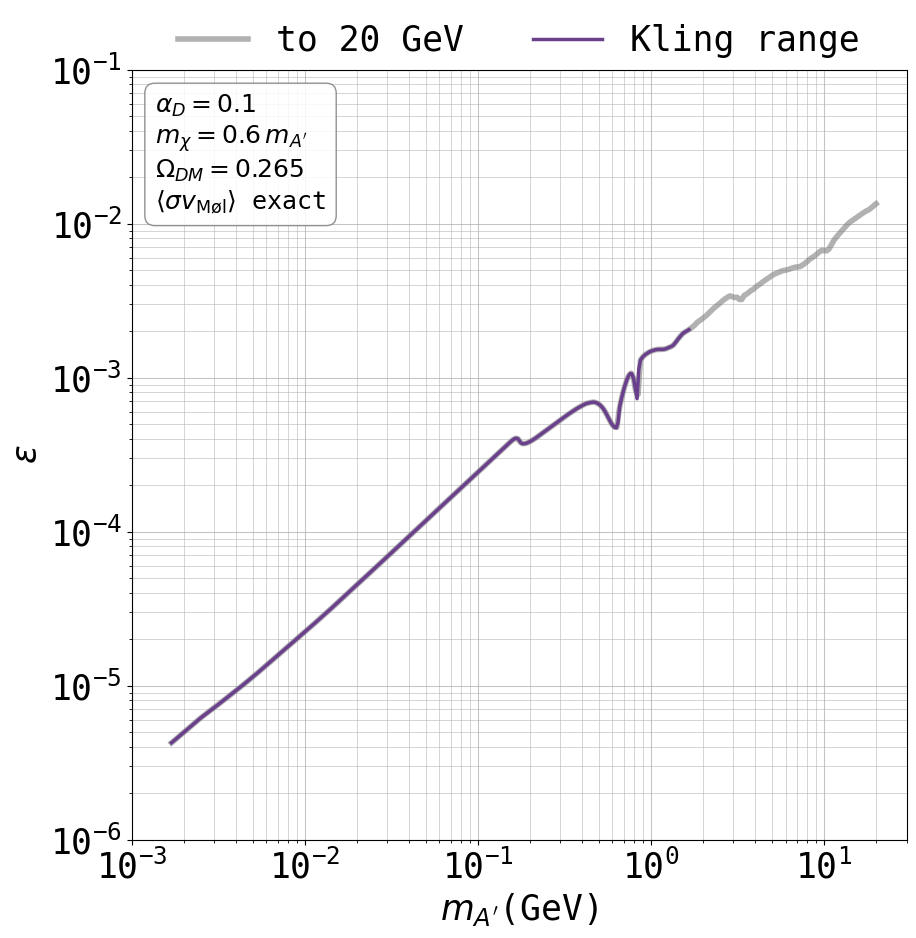

In [47]:
### Confirming the imported line before anything is built on top of it.

# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = '#7e7e7e', linewidth = 4.0,
        alpha = 0.6, label = r"to 20 GeV")
ax.plot(ma_relic, eps_relic, color = '#6a408d', linewidth = 2.5,
        label = r"Kling range")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"$\Omega_{DM} = %s$" % meta_relic["Omega_target"],
                   r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ exact"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 2,                      # spread horizontally
    frameon = False                # removes legend border
)

ax.set_xbound(1e-3, 3e1)
ax.set_ybound(1e-6, 1e-1)

# Save and show the figure:
plt.savefig("figures/relic_line_moller_imported.pdf", bbox_inches='tight')
plt.show()


In [48]:
data_LZ_2024 = np.loadtxt("data/LZ2024_Limit.csv", delimiter=',')

mass_data_LZ_2024 = data_LZ_2024[:, 0]
sigmasidatacm2_LZ_2024 = data_LZ_2024[:, 1]

cm2_to_GeVm2 = 2.5681894616e27          # 1 cm^2 = (hbar c)^-2 GeV^-2
sigmasidataGeV_LZ_2024 = sigmasidatacm2_LZ_2024 * cm2_to_GeVm2

# Interpolating
dd_limit_fun_LZ2024 = interpolate.interp1d(mass_data_LZ_2024, sigmasidataGeV_LZ_2024)

In [49]:
def sig_si_theo(ma, alpha, alphaD, mchi, epsilon):
    """SI DM-nucleon cross section, in GeV^-2."""
    mu = mchi*mp/(mchi + mp)                                   # reduced mass
    return 16*np.pi * epsilon**2 * alpha * alphaD * mu**2 / ma**4

def eps_dd_limit_LZ2024(ma, alpha, alphaD, mchi):
    """epsilon at which sig_si_theo == dd_limit_fun_LZ2024(mchi).

    Points whose mchi falls outside the tabulated LZ mass range are dropped,
    so the limit is only drawn where the experiment actually constrains it.

    Returns (ma_valid, eps_valid): the truncated mediator mass range and the
    corresponding epsilon limits.
    """
    ma, mchi = np.broadcast_arrays(np.atleast_1d(ma), np.atleast_1d(mchi))

    # Keep only the points the interpolator can evaluate:
    inside = (mchi >= mass_data_LZ_2024.min()) & (mchi <= mass_data_LZ_2024.max())
    ma, mchi = ma[inside], mchi[inside]

    sigma_lim = dd_limit_fun_LZ2024(mchi)                      # GeV^-2
    return ma, np.sqrt(sigma_lim / sig_si_theo(ma, alpha, alphaD, mchi, 1.0))


In [50]:
mlims, eplims =eps_dd_limit_LZ2024(ma_dd, alpha, alphaD, mchi_dd)

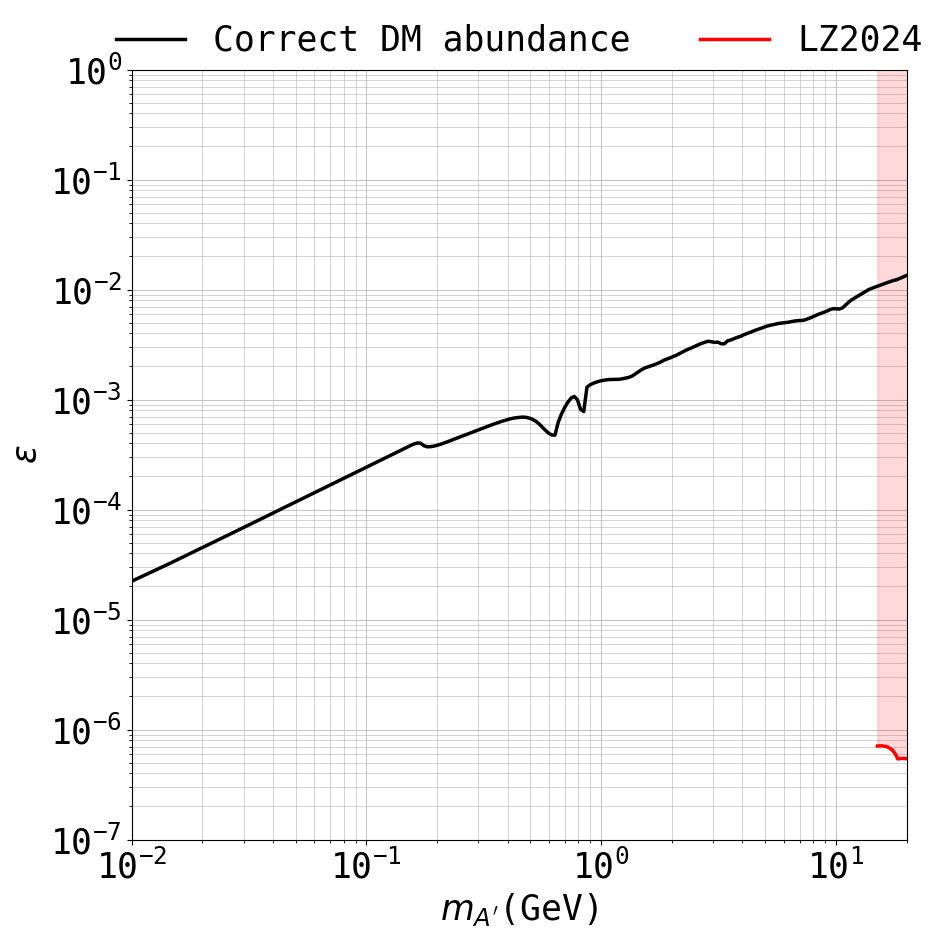

In [51]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Lock the square shape
#ax.set_aspect('equal', adjustable='datalim')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"Correct DM abundance")

ax.plot(mlims, eplims, color = 'red', linewidth = 2.5, label = r"LZ2024")

ax.fill_between(mlims, eplims, 
                1,
                label= rf"Direct detection (Xenon1T)",
                color='red', 
                alpha=0.15, 
                zorder=1)

## Color palets:

dataset_colors = ['#9671bd', '#7e7e7e', '#77b5b6']
dataset_line_colors = ['#6a408d', '#4e4e4e', '#378d94']

# And the colour for the lines (regressions):
regression_color = '#8a8a8a' # <-- neutral grey
# regression_color = '#7f9fa1' # <-- greyish seafoam

'''

ax.scatter(final_data[:,0],final_data[:,1],
            label = "Correct DM abundance",
          s = 90,
          color = dataset_colors[0],
          edgecolors = dataset_line_colors[0],
          linewidths = 1.5,
          zorder = 3
    )

'''

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0,1]  # change the order of legend elements


ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e1
x_range = x_max - x_min

y_min = 1e-7
y_max = 1e0
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)


# Save and show the figure:
plt.savefig("figures/relic_abundance_0.pdf", bbox_inches='tight')
plt.show()

In [52]:
### XENONnT SR0+1 SI limit (FIG 3 A of arXiv:2409.17868), from the .npy points

limits_dir_XENONnT = ("data/XENONnT-light_wimp_data_release-64d2e13/"
                      "light_wimp_data_release/limits")

# The published limit is the power-constrained one; the folder also holds
# xenonnt_si_limit_before_pcl.npy and xenonnt_si_limit_after_dl_pcl.npy.
data_XENONnT_si = np.load(f"{limits_dir_XENONnT}/xenonnt_si_limit_after_pcl.npy")

mass_data_XENONnT_si = data_XENONnT_si['mass_gev']
sigmasidatacm2_XENONnT_si = data_XENONnT_si['limit_cm2']

sigmasidataGeV_XENONnT_si = sigmasidatacm2_XENONnT_si * cm2_to_GeVm2

# Interpolating: only 7 tabulated points spanning 5 decades in sigma, so a
# linear interpolation would overshoot by up to ~5x between the low-mass
# points. The limit is close to a straight line in log-log, so interpolate there.
log_dd_limit_XENONnT_si = interpolate.interp1d(np.log(mass_data_XENONnT_si),
                                               np.log(sigmasidataGeV_XENONnT_si))

def dd_limit_fun_XENONnT_si(mchi):
    return np.exp(log_dd_limit_XENONnT_si(np.log(mchi)))

In [53]:
def eps_dd_limit_XENONnT_si(ma, alpha, alphaD, mchi):
    """epsilon at which sig_si_theo == dd_limit_fun_XENONnT_si(mchi).

    Same construction as eps_dd_limit_LZ2024, against the XENONnT SR0+1
    spin-independent limit. Points whose mchi falls outside the tabulated
    3-12 GeV range are dropped.

    Returns (ma_valid, eps_valid).
    """
    ma, mchi = np.broadcast_arrays(np.atleast_1d(ma), np.atleast_1d(mchi))

    # Keep only the points the interpolator can evaluate:
    inside = ((mchi >= mass_data_XENONnT_si.min())
              & (mchi <= mass_data_XENONnT_si.max()))
    ma, mchi = ma[inside], mchi[inside]

    sigma_lim = dd_limit_fun_XENONnT_si(mchi)                  # GeV^-2
    return ma, np.sqrt(sigma_lim / sig_si_theo(ma, alpha, alphaD, mchi, 1.0))

In [54]:
mlims_XENONnT, eplims_XENONnT = eps_dd_limit_XENONnT_si(ma_dd, alpha, alphaD, mchi_dd)

## FORESEE results: starting point

In [55]:
### Kling's own direct detection bound, data/Kling/bounds_DD.txt.

# Already an exclusion contour in the (m_A', epsilon) plane rather than a
# sigma_SI(mchi) limit, so it needs no reinterpretation: it was drawn for the
# same model, alphaD = 0.1 and mchi = 0.6 m_A' (recovered from the relic file
# in the same folder). It is a closed polygon whose first and last vertices
# are pulled up to epsilon = 1, i.e. the region above the curve is excluded.

bounds_DD_kling = np.loadtxt("data/Kling/bounds_DD.txt")

ma_DD_kling  = bounds_DD_kling[:, 0]
eps_DD_kling = bounds_DD_kling[:, 1]

# The two vertical closure segments are an artefact of closing the polygon,
# so the boundary itself is drawn without them.
ma_DD_kling_line  = ma_DD_kling[1:-1]
eps_DD_kling_line = eps_DD_kling[1:-1]


In [56]:
### The accelerator and beam dump bounds, data/Kling/Lines/bounds_*.txt.

# Sixteen files, same two column (m_A', epsilon) format as bounds_DD.txt and
# the same model assumptions, each a closed polygon bounding an excluded
# region. Several close themselves at epsilon = 1e5, far above the axes, which
# is why they are drawn as filled polygons rather than as curves against a
# ceiling.

import glob
import os

bounds_lines = {}
for path in sorted(glob.glob("data/Kling/Lines/bounds_*.txt")):
    name = os.path.basename(path)[len("bounds_"):-len(".txt")]
    bounds_lines[name] = np.loadtxt(path)


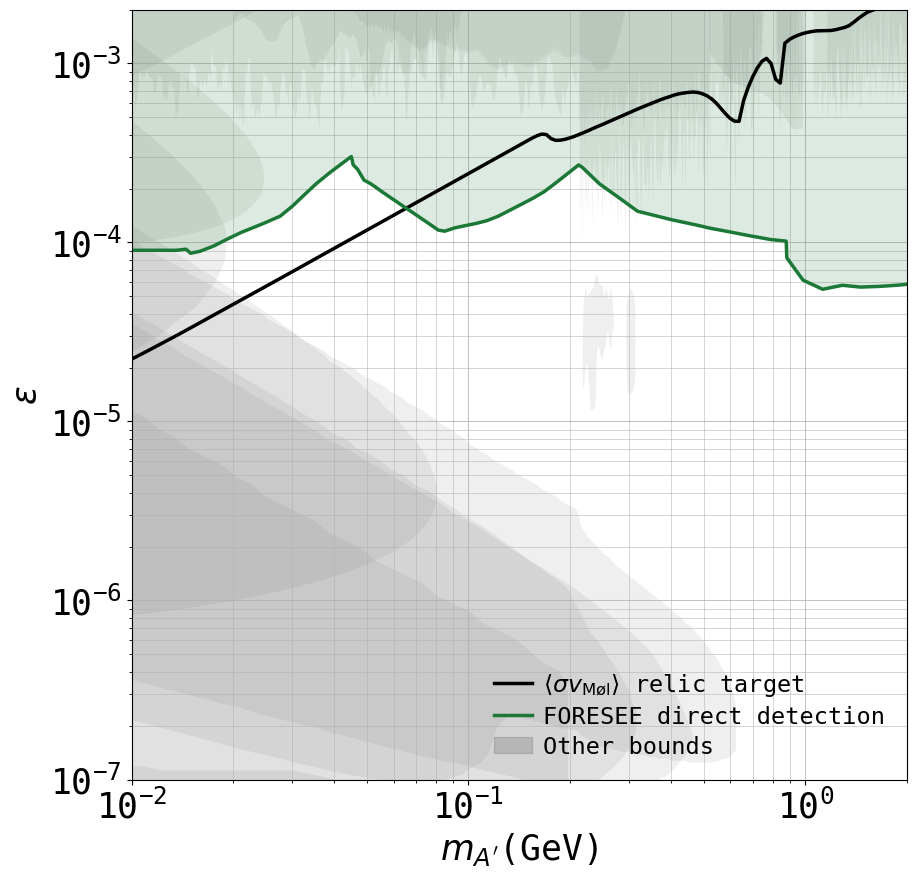

In [57]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

ax.plot(mlims, eplims, color = 'red', linewidth = 2.5)

ax.fill_between(mlims, eplims,
                1,
                color='red',
                alpha=0.15,
                zorder=1)

ax.plot(mlims_XENONnT, eplims_XENONnT,
        color = '#2a78d6', linewidth = 2.5)

ax.fill_between(mlims_XENONnT, eplims_XENONnT,
                1,
                color='#2a78d6',
                alpha=0.15,
                zorder=1)

# All sixteen shaded as one grey family: individually they would need
# sixteen legend entries and would bury the direct detection lines, and what
# matters here is only which part of the plane they already cover.
for _name, _b in bounds_lines.items():
    ax.fill(_b[:, 0], _b[:, 1], color = '#7e7e7e', alpha = 0.12,
            linewidth = 0, zorder = 0)

# One proxy handle for the family as a whole.
ax.fill(np.nan, np.nan, color = '#7e7e7e', alpha = 0.35,
        label = r"Other bounds")

ax.plot(ma_DD_kling_line, eps_DD_kling_line,
        color = '#1b7837', linewidth = 2.5, label = r"FORESEE direct detection")

ax.fill(ma_DD_kling, eps_DD_kling,
        color = '#1b7837',
        alpha = 0.15,
        zorder = 1)

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0,2,1]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e0

y_min = 1e-7
y_max = 2e-3

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_XENONnT_LZ.pdf", bbox_inches='tight')
plt.show()

## Breaking appart the direct detection line:

In [58]:
### Plot one of the limits